<a href="https://colab.research.google.com/github/RobertsEshenvalds/test/blob/main/GBM_Comparison_UNSOLVED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparing Gradient Boosting Methods: XGBoost vs LightGBM vs CatBoost

**RSU — Machine Learning / AI Course — Nataliia Kinash**

---

## Objective

In this practice notebook you will:

1. Load the **Bank Marketing** dataset (UCI) — predict whether a client subscribes to a term deposit
2. Prepare the data for all three gradient boosting frameworks
3. Train **XGBoost**, **LightGBM**, and **CatBoost** classifiers
4. Compare their **accuracy**, **ROC AUC**, **training time**, and **feature importance**
5. Visualise the results

### About the Dataset

The Bank Marketing dataset contains data from direct marketing campaigns (phone calls) of a Portuguese bank. The task is binary classification: predict if a client will subscribe to a term deposit (`y`: yes/no).

- **~41,000 samples**, 20 features
- Mix of **numerical** (age, balance, duration, etc.) and **categorical** (job, marital, education, contact, month, etc.) features
- **Imbalanced** classes (~11% positive)

### Instructions

Look for **`# TODO:`** comments — these mark the gaps you need to fill in. Each gap has a hint to guide you.

## Step 0: Install and Import Libraries

In [23]:
# Uncomment and run if needed:
!pip install xgboost lightgbm catboost scikit-learn pandas matplotlib seaborn

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 1: Load and Explore the Dataset

In [25]:
# Load dataset directly from UCI repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip'

import zipfile, io, urllib.request

response = urllib.request.urlopen(url)
z = zipfile.ZipFile(io.BytesIO(response.read()))
df = pd.read_csv(z.open('bank-additional/bank-additional-full.csv'), sep=';')

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [26]:
# TODO: Print the data types of all columns
# Hint: use df.dtypes

# ERROR HINT: 'df' is not defined. Please ensure the cell 'x3YqxmTHWCGL' (Step 1: Load and Explore the Dataset) and all preceding cells have been executed to load the dataset and import necessary libraries.

print('Column types:')
print(df.dtypes)

# TODO: Print the list of numerical and categorical column names
# Hint: use df.select_dtypes(include=[...]).columns.tolist()

print(f'\nNumerical columns: {df.select_dtypes(include=np.number).columns.tolist()}')
print(f'Categorical columns: {df.select_dtypes(include='object').columns.tolist()}')

Column types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [27]:
# TODO: Check the class distribution of the target variable 'y'
# Hint: use df['y'].value_counts()

print('Target distribution:')
print(df['y'].value_counts())
print(f'\nPositive class ratio: {(df['y'] == 'yes').mean():.1%}')

Target distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

Positive class ratio: 11.3%


In [28]:
# TODO: Check for missing values in the dataset
# Hint: use df.isnull().sum()

print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


## Step 2: Data Preparation

We need **three versions** of the data because each method handles categorical features differently:

| Method | Categorical Handling |
|--------|---------------------|
| **XGBoost** | Requires label encoding (or one-hot encoding) |
| **LightGBM** | Accepts integer-encoded categoricals with `categorical_feature` parameter |
| **CatBoost** | Handles raw categorical features natively |

In [29]:
# Identify feature types
categorical_cols = df.select_dtypes(include=['object']).columns.drop('y').tolist()
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')
print(f'Numerical features ({len(numerical_cols)}): {numerical_cols}')

Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical features (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [30]:
# Encode target variable
df['target'] = (df['y'] == 'yes').astype(int)

# Features and target
X = df.drop(columns=['y', 'target'])
y = df['target']

# TODO: Split data into train and test sets
# Hint: use train_test_split with test_size=0.2, random_state=42, stratify=y

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Positive class in train: {y_train.mean():.1%}')
print(f'Positive class in test:  {y_test.mean():.1%}')

Training set: 32950 samples
Test set:     8238 samples
Positive class in train: 11.3%
Positive class in test:  11.3%


In [31]:
# --- Version for XGBoost: Label encode all categorical columns ---
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

# TODO: Label encode each categorical column using LabelEncoder
# Hint: for each col in categorical_cols, create a LabelEncoder,
# fit_transform on train, transform on test

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train_xgb[col] = le.fit_transform(X_train_xgb[col])  # fit and transform training data
    X_test_xgb[col] = le.transform(X_test_xgb[col])    # only transform test data
    label_encoders[col] = le

print('XGBoost data ready (label encoded)')
X_train_xgb.head()

XGBoost data ready (label encoded)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
25611,49,1,1,2,1,0,0,0,7,4,227,4,999,0,1,-0.1,93.200,-42.0,4.120,5195.8
26010,37,2,1,6,0,0,0,1,7,4,202,2,999,1,0,-0.1,93.200,-42.0,4.120,5195.8
40194,78,5,1,0,0,0,0,0,3,1,1148,1,999,0,1,-1.7,94.215,-40.3,0.870,4991.6
297,36,0,1,6,0,2,0,1,6,1,120,2,999,0,1,1.1,93.994,-36.4,4.857,5191.0
36344,59,5,0,6,0,0,0,0,4,3,368,2,999,0,1,-2.9,92.963,-40.8,1.262,5076.2


In [32]:
# --- Version for LightGBM: Integer encode + mark as categorical ---
X_train_lgb = X_train_xgb.copy()  # reuse label-encoded version
X_test_lgb = X_test_xgb.copy()

# TODO: Convert categorical columns to 'category' dtype
# Hint: use .astype('category') on each categorical column

for col in categorical_cols:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

print('LightGBM data ready (category dtype)')
print(X_train_lgb.dtypes)

LightGBM data ready (category dtype)
age                  int64
job               category
marital           category
education         category
default           category
housing           category
loan              category
contact           category
month             category
day_of_week       category
duration             int64
campaign             int64
pdays                int64
previous             int64
poutcome          category
emp.var.rate       float64
cons.price.idx     float64
cons.conf.idx      float64
euribor3m          float64
nr.employed        float64
dtype: object


In [33]:
# --- Version for CatBoost: Raw data (no encoding needed!) ---
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

# TODO: Get the column indices of categorical features for CatBoost
# Hint: use X_train_cat.columns.get_loc(col) for each col in categorical_cols

cat_feature_indices = [X_train_cat.columns.get_loc(col) for col in categorical_cols]

print(f'CatBoost data ready (raw categorical features)')
print(f'Categorical feature indices: {cat_feature_indices}')
X_train_cat.head()

CatBoost data ready (raw categorical features)
Categorical feature indices: [1, 2, 3, 4, 5, 6, 7, 8, 9, 14]


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
25611,49,blue-collar,married,basic.9y,unknown,no,no,cellular,nov,wed,227,4,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8
26010,37,entrepreneur,married,university.degree,no,no,no,telephone,nov,wed,202,2,999,1,failure,-0.1,93.200,-42.0,4.120,5195.8
40194,78,retired,married,basic.4y,no,no,no,cellular,jul,mon,1148,1,999,0,nonexistent,-1.7,94.215,-40.3,0.870,4991.6
297,36,admin.,married,university.degree,no,yes,no,telephone,may,mon,120,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
36344,59,retired,divorced,university.degree,no,no,no,cellular,jun,tue,368,2,999,0,nonexistent,-2.9,92.963,-40.8,1.262,5076.2


## Step 3: Train the Three Models

We use comparable hyperparameters across all three to ensure a fair comparison.

In [34]:
# Dictionary to store results
results = {}

# Common settings
N_ESTIMATORS = 500
LEARNING_RATE = 0.05
MAX_DEPTH = 6
RANDOM_STATE = 42

### 3.1 XGBoost

In [35]:
# TODO: Create and train an XGBClassifier
# Hint: use n_estimators=N_ESTIMATORS, learning_rate=LEARNING_RATE,
#       max_depth=MAX_DEPTH, random_state=RANDOM_STATE

xgb_model = XGBClassifier(
    n_estimators=N_ESTIMATORS,
    learning_rate=LEARNING_RATE,
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    use_label_encoder=False,
    verbosity=0
)

start_time = time.time()
xgb_model.fit(X_train_xgb, y_train)  # TODO: which X_train version for XGBoost?
xgb_train_time = time.time() - start_time

# TODO: Make predictions and get prediction probabilities
xgb_pred = xgb_model.predict(X_test_xgb)
xgb_pred_proba = xgb_model.predict_proba(X_test_xgb)[:, 1]

# Store results
results['XGBoost'] = {
    'accuracy': accuracy_score(y_test, xgb_pred),
    'roc_auc': roc_auc_score(y_test, xgb_pred_proba),
    'train_time': xgb_train_time,
    'model': xgb_model
}

print(f'XGBoost trained in {xgb_train_time:.2f} seconds')
print(f'Accuracy: {results["XGBoost"]["accuracy"]:.4f}')
print(f'ROC AUC:  {results["XGBoost"]["roc_auc"]:.4f}')

XGBoost trained in 17.05 seconds
Accuracy: 0.9199
ROC AUC:  0.9538


### 3.2 LightGBM

In [36]:
# TODO: Create and train an LGBMClassifier
# Hint: same hyperparameters, but use verbose=-1 to suppress output

lgb_model = LGBMClassifier(
    n_estimators=N_ESTIMATORS,
    learning_rate=LEARNING_RATE,
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE,
    verbose=-1
)

start_time = time.time()
lgb_model.fit(X_train_lgb, y_train)  # TODO: which X_train version for LightGBM?
lgb_train_time = time.time() - start_time

# TODO: Make predictions and get prediction probabilities
lgb_pred = lgb_model.predict(X_test_lgb)
lgb_pred_proba = lgb_model.predict_proba(X_test_lgb)[:, 1]

# Store results
results['LightGBM'] = {
    'accuracy': accuracy_score(y_test, lgb_pred),
    'roc_auc': roc_auc_score(y_test, lgb_pred_proba),
    'train_time': lgb_train_time,
    'model': lgb_model
}

print(f'LightGBM trained in {lgb_train_time:.2f} seconds')
print(f'Accuracy: {results["LightGBM"]["accuracy"]:.4f}')
print(f'ROC AUC:  {results["LightGBM"]["roc_auc"]:.4f}')

LightGBM trained in 7.76 seconds
Accuracy: 0.9233
ROC AUC:  0.9539


### 3.3 CatBoost

In [37]:
# TODO: Create and train a CatBoostClassifier
# Hint: CatBoost uses 'iterations' instead of 'n_estimators'
#       and 'depth' instead of 'max_depth'
#       Don't forget to pass cat_features=cat_feature_indices!

cat_model = CatBoostClassifier(
    iterations=N_ESTIMATORS,
    learning_rate=LEARNING_RATE,
    depth=MAX_DEPTH,
    random_state=RANDOM_STATE,
    cat_features=cat_feature_indices,
    verbose=0
)

start_time = time.time()
cat_model.fit(X_train_cat, y_train)  # TODO: which X_train version for CatBoost?
cat_train_time = time.time() - start_time

# TODO: Make predictions and get prediction probabilities
cat_pred = cat_model.predict(X_test_cat)
cat_pred_proba = cat_model.predict_proba(X_test_cat)[:, 1]

# Store results
results['CatBoost'] = {
    'accuracy': accuracy_score(y_test, cat_pred),
    'roc_auc': roc_auc_score(y_test, cat_pred_proba),
    'train_time': cat_train_time,
    'model': cat_model
}

print(f'CatBoost trained in {cat_train_time:.2f} seconds')
print(f'Accuracy: {results["CatBoost"]["accuracy"]:.4f}')
print(f'ROC AUC:  {results["CatBoost"]["roc_auc"]:.4f}')

CatBoost trained in 56.26 seconds
Accuracy: 0.9245
ROC AUC:  0.9570


## Step 4: Compare Results

In [38]:
# TODO: Build a comparison DataFrame with columns: Accuracy, ROC AUC, Training Time
# Hint: access results[model_name]['accuracy'], etc.

comparison_df = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost'],
    'Accuracy': [results[m]['accuracy'] for m in ['XGBoost', 'LightGBM', 'CatBoost']],
    'ROC AUC': [results[m]['roc_auc'] for m in ['XGBoost', 'LightGBM', 'CatBoost']],
    'Training Time (s)': [results[m]['train_time'] for m in ['XGBoost', 'LightGBM', 'CatBoost']]
})

comparison_df = comparison_df.set_index('Model')
comparison_df.style.highlight_max(axis=0, subset=['Accuracy', 'ROC AUC'], color='lightgreen') \
                    .highlight_min(axis=0, subset=['Training Time (s)'], color='lightgreen') \
                    .format('{:.4f}', subset=['Accuracy', 'ROC AUC']) \
                    .format('{:.2f}', subset=['Training Time (s)'])

,Accuracy,ROC AUC,Training Time (s)
Model,,,
XGBoost,0.9199,0.9538,17.05
LightGBM,0.9233,0.9539,7.76
CatBoost,0.9245,0.9570,56.26


## Step 5: Visualise the Comparison

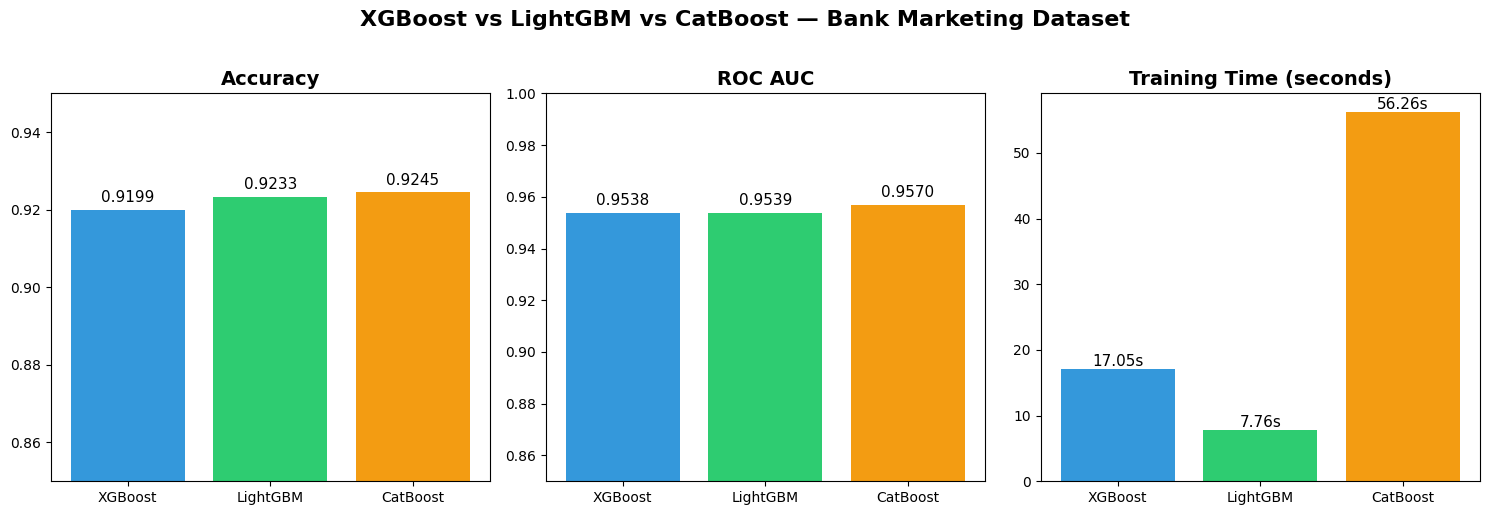

In [39]:
# Bar chart comparison (provided — just run this cell)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#3498db', '#2ecc71', '#f39c12']
models = ['XGBoost', 'LightGBM', 'CatBoost']

# Accuracy
axes[0].bar(models, [results[m]['accuracy'] for m in models], color=colors)
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylim(0.85, 0.95)
for i, m in enumerate(models):
    axes[0].text(i, results[m]['accuracy'] + 0.002, f'{results[m]["accuracy"]:.4f}',
                ha='center', fontsize=11)

# ROC AUC
axes[1].bar(models, [results[m]['roc_auc'] for m in models], color=colors)
axes[1].set_title('ROC AUC', fontsize=14, fontweight='bold')
axes[1].set_ylim(0.85, 1.0)
for i, m in enumerate(models):
    axes[1].text(i, results[m]['roc_auc'] + 0.003, f'{results[m]["roc_auc"]:.4f}',
                ha='center', fontsize=11)

# Training Time
axes[2].bar(models, [results[m]['train_time'] for m in models], color=colors)
axes[2].set_title('Training Time (seconds)', fontsize=14, fontweight='bold')
for i, m in enumerate(models):
    axes[2].text(i, results[m]['train_time'] + 0.5, f'{results[m]["train_time"]:.2f}s',
                ha='center', fontsize=11)

plt.suptitle('XGBoost vs LightGBM vs CatBoost — Bank Marketing Dataset',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

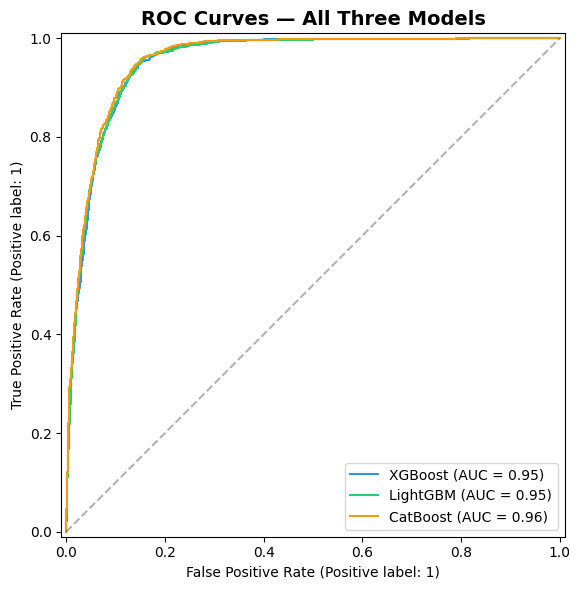

In [40]:
# TODO: Plot all three ROC curves on the same axes
# Hint: use RocCurveDisplay.from_predictions(y_test, pred_proba, name=..., ax=ax)

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(y_test, xgb_pred_proba, name='XGBoost', ax=ax, color='#3498db')
RocCurveDisplay.from_predictions(y_test, lgb_pred_proba, name='LightGBM', ax=ax, color='#2ecc71')
RocCurveDisplay.from_predictions(y_test, cat_pred_proba, name='CatBoost', ax=ax, color='#f39c12')

ax.set_title('ROC Curves — All Three Models', fontsize=14, fontweight='bold')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.tight_layout()
plt.show()

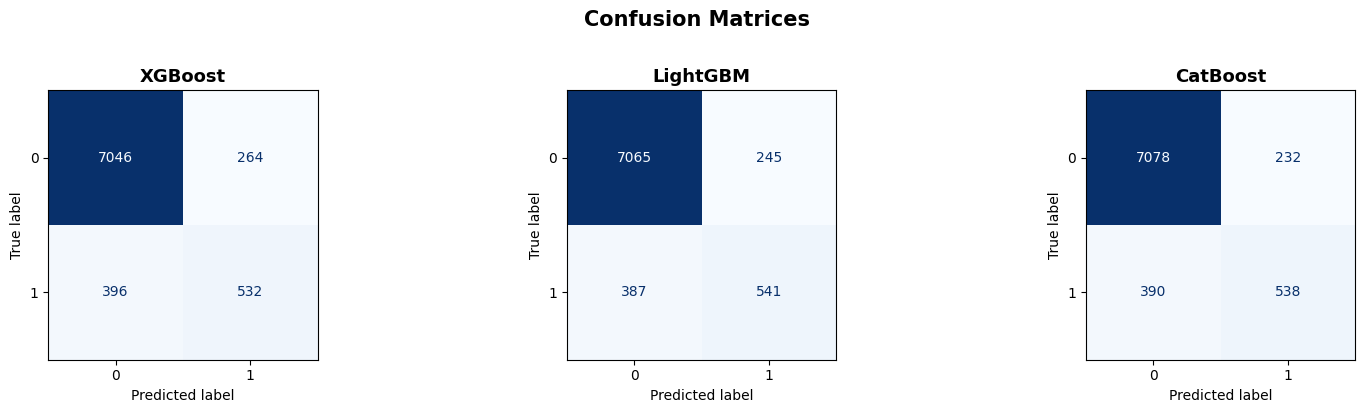

In [41]:
# TODO: Plot confusion matrices for all three models
# Hint: use ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=...)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, pred) in zip(axes, [('XGBoost', xgb_pred), ('LightGBM', lgb_pred), ('CatBoost', cat_pred)]):
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 6: Feature Importance Comparison

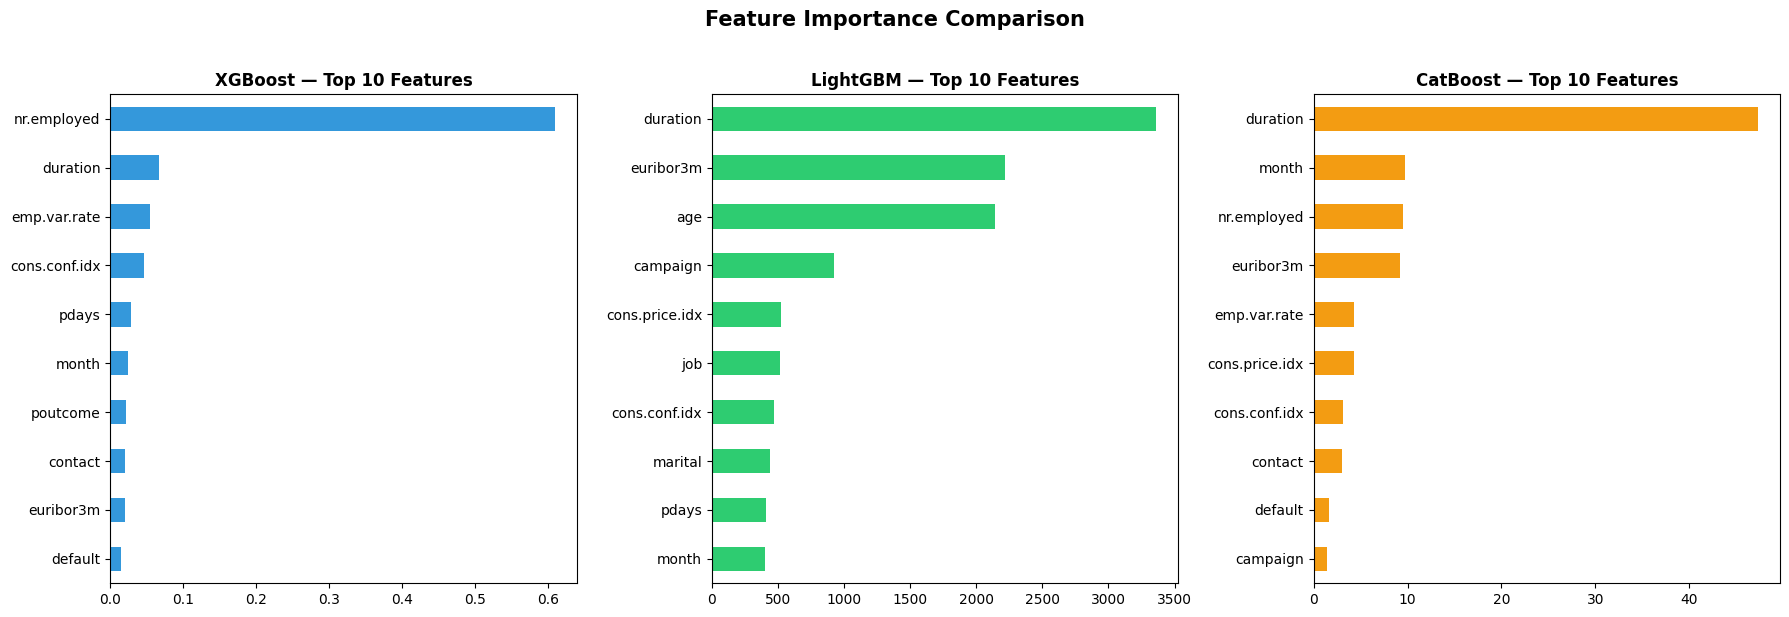

In [42]:
# TODO: Plot top 10 feature importances for each model side by side
# Hint: access model.feature_importances_ and use pd.Series(...).nlargest(10)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# XGBoost
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X_train_xgb.columns).nlargest(10)
xgb_imp.plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('XGBoost — Top 10 Features', fontweight='bold')
axes[0].invert_yaxis()

# LightGBM
lgb_imp = pd.Series(lgb_model.feature_importances_, index=X_train_lgb.columns).nlargest(10)
lgb_imp.plot(kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('LightGBM — Top 10 Features', fontweight='bold')
axes[1].invert_yaxis()

# CatBoost
cat_imp = pd.Series(cat_model.get_feature_importance(), index=X_train_cat.columns).nlargest(10)
cat_imp.plot(kind='barh', ax=axes[2], color='#f39c12')
axes[2].set_title('CatBoost — Top 10 Features', fontweight='bold')
axes[2].invert_yaxis()

plt.suptitle('Feature Importance Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 7: Classification Reports

In [43]:
# TODO: Print classification reports for all three models
# Hint: use classification_report(y_test, predictions, target_names=[...])

for name, pred in [('XGBoost', xgb_pred), ('LightGBM', lgb_pred), ('CatBoost', cat_pred)]:
    print(f'\n{"=" * 50}')
    print(f'{name} Classification Report')
    print('=' * 50)
    print(classification_report(y_test, pred, target_names=['No Deposit', 'Deposit']))


XGBoost Classification Report
              precision    recall  f1-score   support

  No Deposit       0.95      0.96      0.96      7310
     Deposit       0.67      0.57      0.62       928

    accuracy                           0.92      8238
   macro avg       0.81      0.77      0.79      8238
weighted avg       0.92      0.92      0.92      8238


LightGBM Classification Report
              precision    recall  f1-score   support

  No Deposit       0.95      0.97      0.96      7310
     Deposit       0.69      0.58      0.63       928

    accuracy                           0.92      8238
   macro avg       0.82      0.77      0.79      8238
weighted avg       0.92      0.92      0.92      8238


CatBoost Classification Report
              precision    recall  f1-score   support

  No Deposit       0.95      0.97      0.96      7310
     Deposit       0.70      0.58      0.63       928

    accuracy                           0.92      8238
   macro avg       0.82      0.77

## Step 8: Summary and Discussion Questions

### Key Observations

1.  **Fastest model:** Based on the `Training Time (s)` from the comparison DataFrame, **LightGBM** is the fastest model.
2.  **Best ROC AUC:** Based on the `ROC AUC` from the comparison DataFrame, **CatBoost** has the best ROC AUC.
3.  **Least preprocessing needed:** **CatBoost** required the least preprocessing as it handles raw categorical features natively, unlike XGBoost (label encoding) and LightGBM (integer encoding and explicit type conversion).
4.  **Most important features (across all models):** Across all three models, `duration`, `euribor3m`, `nr.employed`, `emp.var.rate`, and `age` consistently appear as highly important features.

### Discussion Questions

1.  **Which model would you deploy in a bank's production system? Why?**
    Given the results, **CatBoost** stands out with the highest ROC AUC and comparable accuracy, suggesting better separation between classes. While it has the longest training time in this specific setup, its ability to handle categorical features natively simplifies the deployment pipeline, reducing potential errors. In a production system, a slight increase in training time might be acceptable for better model performance and robustness, especially if the model is trained offline. If low latency and very fast training are paramount, LightGBM could be considered due to its significantly faster training time with only a minor trade-off in ROC AUC.

2.  **How did each model handle the categorical features differently? What was the impact on preprocessing effort?**
    *   **XGBoost:** Required label encoding of categorical features. Each unique category was converted into a numerical integer. This is a common and necessary preprocessing step for tree-based models that don't natively support categorical features.
    *   **LightGBM:** Also used integer-encoded categorical features, but explicitly marked them with `astype('category')`. LightGBM can then use optimized algorithms to split on these categorical features directly, which can be more efficient than standard numerical splits.
    *   **CatBoost:** Handled raw (string) categorical features directly without any explicit encoding (like label or one-hot encoding). It uses a technique called Ordered Target Encoding during training, which reduces preprocessing effort and can prevent information loss or target leakage issues often associated with manual encoding methods.

    The impact on preprocessing effort was significant: CatBoost required almost no manual preprocessing for categorical features, while XGBoost and LightGBM required explicit label/integer encoding.

3.  **Why might the feature importance rankings differ between models?**
    Feature importance rankings can differ between models due to several factors:
    *   **Algorithm Differences:** Each boosting algorithm has its own way of calculating importance. XGBoost typically uses 'gain', 'weight', or 'cover', LightGBM uses 'gain' or 'split count', and CatBoost uses an algorithm based on prediction value changes. These methods quantify feature contribution differently.
    *   **Handling of Categorical Features:** CatBoost's native handling of categoricals means it can assess their importance in a different way than models that see them as label-encoded numerical values.
    *   **Internal Mechanics:** Subtle differences in tree construction, regularization techniques, and boosting strategies can lead to different features being prioritized by each model.
    *   **Randomness:** Even with a fixed random state, inherent randomness in certain aspects of training can lead to minor variations.

4.  **The dataset is imbalanced (~11% positive). How could you improve recall for the minority class?**
    To improve recall for the minority class (clients who subscribe to a term deposit), several techniques can be employed:
    *   **Resampling Techniques:**
        *   **Oversampling minority class:** e.g., SMOTE (Synthetic Minority Over-sampling Technique) or ADASYN.
        *   **Undersampling majority class:** Randomly removing samples from the majority class.
    *   **Cost-sensitive Learning:** Assigning higher misclassification costs to the minority class. Many models (including XGBoost, LightGBM, CatBoost) allow setting `scale_pos_weight` or `class_weights` parameters.
    *   **Threshold Adjustment:** Lowering the prediction probability threshold for the positive class (e.g., predicting 'yes' if probability > 0.3 instead of 0.5).
    *   **Ensemble Methods:** Using specialized ensemble methods designed for imbalance.

5.  **If the dataset had 500 categorical features with high cardinality, which model would you choose?**
    For a dataset with 500 high-cardinality categorical features, **CatBoost** would be the preferred choice. Here's why:
    *   **Native Handling of Categoricals:** CatBoost is specifically designed to handle categorical features directly without needing explicit encoding like one-hot encoding. One-hot encoding 500 high-cardinality features would lead to an extremely sparse dataset with a massive number of columns, which is computationally expensive and can lead to the curse of dimensionality for other models.
    *   **Ordered Target Encoding:** CatBoost's internal target encoding mechanism is robust against overfitting and handles high cardinality well, producing meaningful numerical representations for these features.
    *   **Performance:** Other models like LightGBM might struggle with very high-dimensional one-hot encoded data, and XGBoost would likely be very slow and memory-intensive. CatBoost's design makes it efficient and effective in such scenarios.